# Momentum Method. DBN Networks.

In [1]:
# Check for all needed packages
import time

import numpy
import matplotlib
import mnists
# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

# Tested in Python 3.14.3 with:
# numpy==2.4.3
# matplotlib==3.10.8
# mnists==0.4.1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

try:
    import mkl
    mkl.set_num_threads(2)
except ImportError:
    print("Intel Math Kernel Library (MKL) does not always work on every machine. "
          "Continuing without `mkl`.")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

Intel Math Kernel Library (MKL) does not always work on every machine. Continuing without `mkl`.


### Handy utility functions

In [3]:
def append_ones(matrix: np.ndarray) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate((matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=1)


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)
def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)

def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)

def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos:(pos + size)] for pos in range(0, len(seq), size)])

def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(shape=(rows_count * (tile_height + space_between_tiles) - space_between_tiles,
                                 cols_count * (tile_width + space_between_tiles) - space_between_tiles))
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0:x_0 + tile_height, y_0:y_0 + tile_width] = examples[r, c]

    return img_matrix

def preview_tiles(examples: np.ndarray) -> np.ndarray:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap='gray', interpolation='none')
    plt.axis('off')
    plt.show()

# MNIST dataset

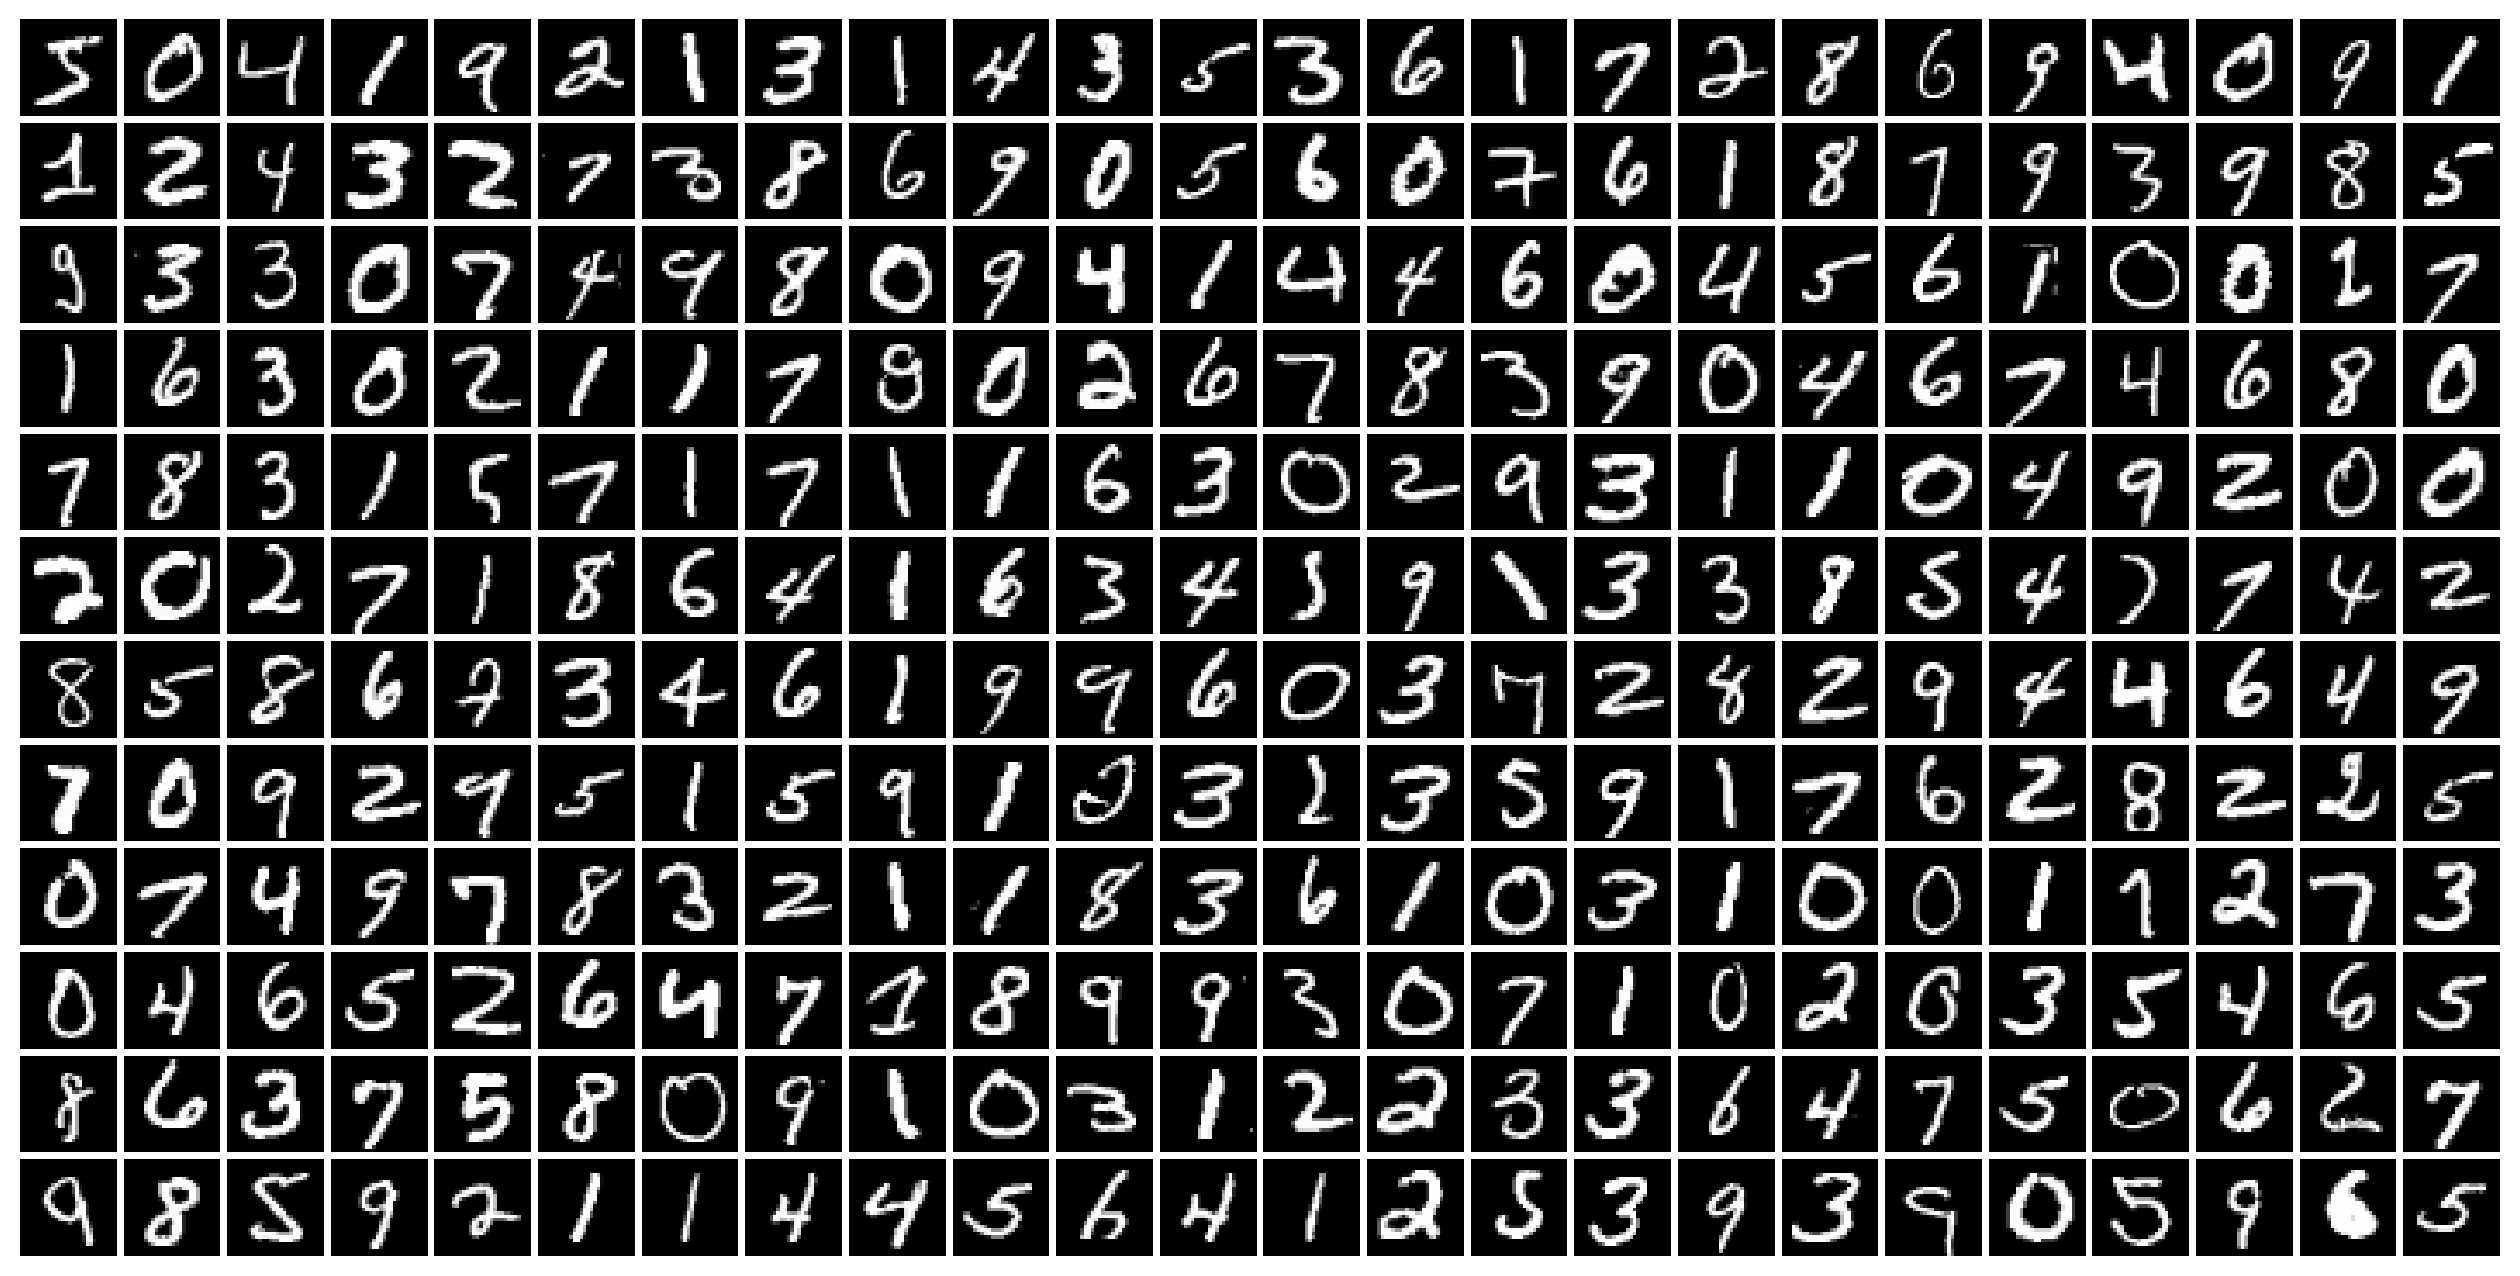

In [4]:
from mnists import MNIST
mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28 # [px]

def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[:12*24], shape=shape)

mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

preview_tiles(mnist_digits)

# Restricted Boltzmann Machine & Contrastive Divergence algorithm

In [7]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Applies the sigmoid (logistic) activation function element-wise.

    Squashes each value in `x` to the range (0, 1), which is
    interpreted as an activation probability in the RBM context.
    """
    return 1.0 / (1.0 + np.exp(-x))

class RestrictedBoltzmannMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:  Number of visible (input) units, excluding the bias.
        hidden_size:   Number of hidden units, excluding the bias.
        learning_rate: Step size used during contrastive divergence updates.
        W:             Weight matrix of shape (visible_size+1, hidden_size+1).
        momentum:      Momentum coefficient
    """
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        learning_rate: float,
        momentum: float = 0.0
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.momentum = momentum
        
        self.reset()
    
    def reset(self):
        self.W = np.random.normal(
            scale=0.01, 
            size=(self.visible_size+1, self.hidden_size+1),
        ).astype(np.float32)
        self.W[:, -1] = 0.0 # zero hidden-bias weights
        self.W[-1, :] = 0.0 # zero visible-bias weights
        self.M = zeros(self.visible_size+1, self.hidden_size+1) 

In [8]:
def reconstruction_error(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.

    Runs a single forward-backward pass (encode then decode) without
    weight updates and returns the average squared difference between
    the original visible units and their reconstructions.

    Args:
        rbm:        The trained (or partially trained) RBM.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    with the bias column appended.

    Returns:
        A scalar float: sum of squared errors divided by the number
        of observations.
    """
    observations_count = minibatch.shape[0]

    # hidden probabilities
    hidden = sigmoid(minibatch @ rbm.W)
    hidden[:, -1] = 1.0  # bias unit

    # visible reconstruction probabilities
    visible = sigmoid(hidden @ rbm.W.T)[:, :-1]

    error = np.sum((minibatch[:, :-1] - visible) ** 2) / observations_count
    return float(error)

In [11]:
import time

# Declaration for the following functions. Will be defined in section 1.
def cdk(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray, k: int = 1) -> None:
    raise NotImplementedError("Not implemented yet!")

def train_epoch(
    rbm: RestrictedBoltzmannMachine, 
    dataset: np.ndarray, 
    batch_size: int
) -> None:
    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(rbm, batch)
        if batch_idx % round(batches_limit / 50) == 0: print("#", end="")

def run_training(
    rbm: RestrictedBoltzmannMachine, 
    dataset: np.ndarray, 
    monitoring_set: np.ndarray, 
    batch_size: int, 
    epochs_count: int
) -> None:
    for epoch in range(epochs_count):
        print(f"Epoch {epoch}:", end="\t")
        
        if epoch == 5:
            rbm.momentum = 0.8

        start_time = time.time()
        train_epoch(rbm, dataset, batch_size)
        elapsed = time.time() - start_time
        
        error = reconstruction_error(rbm, monitoring_set)
        print("\telapsed: {0:>2.2f}s, reconstruction error: {1:>2.2f}".format(elapsed, error))

    print("Training finished!")

In [12]:
def draw_filters(rbm: RestrictedBoltzmannMachine) -> None:
    """
    Visualises the learned RBM weight filters as a grid of 28x28 tiles.

    Transposes W, strips the bias row/column, reshapes the hidden-unit
    weight vectors into 28x28 images, clips extreme values to [-1, 1],
    and renders them using `tiles`.
    """
    
    filters: np.ndarray = np.reshape(
        np.transpose(rbm.W)[:-1, :-1],
        shape=(8, -1, TILE_DIM, TILE_DIM),
    )
    filters = np.clip(filters, -1, 1)
    preview_tiles(filters)


# 1. RBM Training with momentum

In [ ]:
def cdk(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray, k: int = 1) -> None:
    observations_count = minibatch.shape[0]

    # -------- Positive phase --------
    positive_visible = minibatch  # already contains bias column
    positive_hidden_probs = append_ones(zeros(observations_count, rbm.hidden_size))
    positive_hidden_probs[:, :-1] = sigmoid(positive_visible @ rbm.W[:, :-1])

    # Sample hidden states from probabilities
    hidden_states = append_ones(zeros(observations_count, rbm.hidden_size))
    hidden_states[:, :-1] = (
        positive_hidden_probs[:, :-1] > rand(observations_count, rbm.hidden_size)
    ).astype(np.float32)

    # -------- Negative phase (Gibbs sampling) --------
    negative_visible = None
    negative_hidden_probs = None

    for _ in range(k):
        # Reconstruct visible units from hidden states
        negative_visible = append_ones(zeros(observations_count, rbm.visible_size))
        negative_visible[:, :-1] = sigmoid(hidden_states @ rbm.W.T[:, :-1])

        # Compute hidden probabilities from reconstructed visible units
        negative_hidden_probs = append_ones(zeros(observations_count, rbm.hidden_size))
        negative_hidden_probs[:, :-1] = sigmoid(negative_visible @ rbm.W[:, :-1])

        # Sample hidden states for next Gibbs step
        hidden_states = append_ones(zeros(observations_count, rbm.hidden_size))
        hidden_states[:, :-1] = (
            negative_hidden_probs[:, :-1] > rand(observations_count, rbm.hidden_size)
        ).astype(np.float32)

    # -------- Weight update --------
    positive_gradient = positive_visible.T @ positive_hidden_probs
    negative_gradient = negative_visible.T @ negative_hidden_probs

    delta = rbm.learning_rate * (positive_gradient - negative_gradient) / observations_count

    rbm.M = rbm.momentum * rbm.M + delta
    rbm.W += rbm.M

In [10]:
DATASET_SIZE: int = 20000 # 60000 for whole dataset
DIGIT_SIZE: int = 28

VISIBLE_LAYER_SIZE: int = DIGIT_SIZE * DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 128

mnist_train = mnist.train_images().astype(np.float32) / 255.0
np.random.shuffle(mnist_train)
dataset = np.reshape(mnist_train[:DATASET_SIZE], shape=(DATASET_SIZE, DIGIT_SIZE*DIGIT_SIZE))
dataset = append_ones(dataset)

monitoring_indeces = np.random.choice(DATASET_SIZE, 256, replace=False)
monitoring_set = dataset[monitoring_indeces]

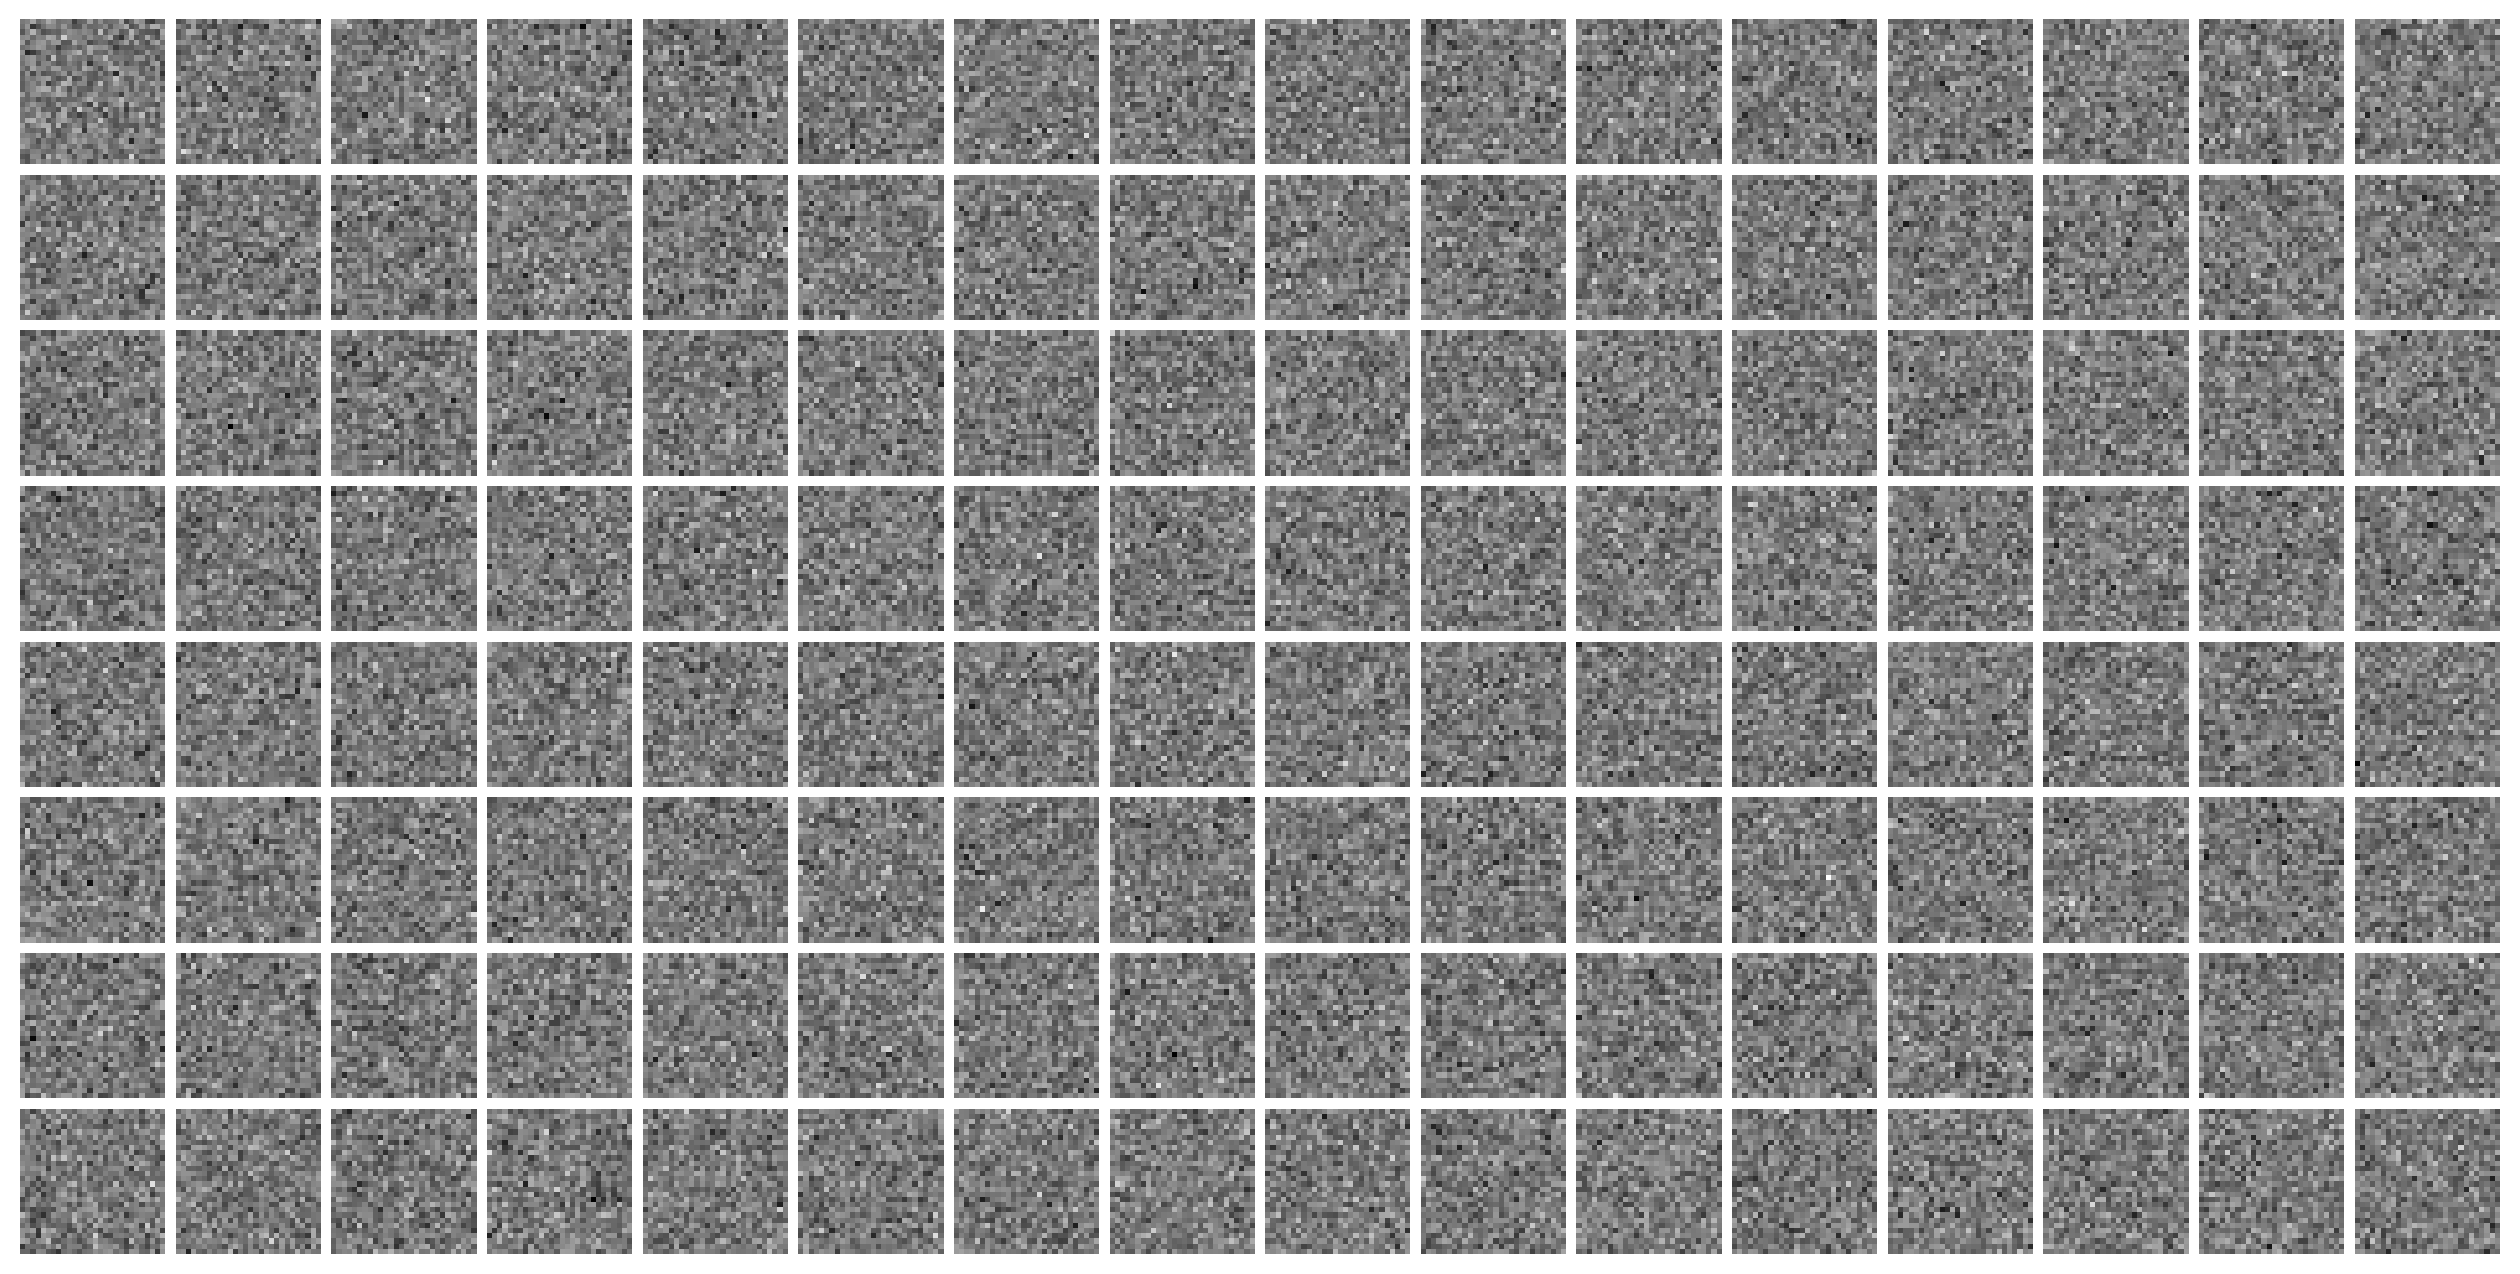

Epoch 0:	#####################################################	elapsed: 5.65s, reconstruction error: 26.50
Epoch 1:	#####################################################	elapsed: 4.11s, reconstruction error: 21.37
Epoch 2:	#####################################################	elapsed: 1.34s, reconstruction error: 18.77
Epoch 3:	#####################################################	elapsed: 0.98s, reconstruction error: 17.29
Epoch 4:	#####################################################	elapsed: 2.56s, reconstruction error: 16.29
Epoch 5:	#####################################################	elapsed: 3.26s, reconstruction error: 15.00
Epoch 6:	#####################################################	elapsed: 0.95s, reconstruction error: 14.11
Epoch 7:	#####################################################	elapsed: 1.06s, reconstruction error: 13.31
Epoch 8:	#####################################################	elapsed: 0.97s, reconstruction error: 12.84
Epoch 9:	############################

/tmp/ipykernel_30741/2078386248.py:8: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


###############################################	elapsed: 0.61s, reconstruction error: 10.46
Epoch 36:	#####################################################	elapsed: 0.58s, reconstruction error: 10.39
Epoch 37:	#####################################################	elapsed: 0.58s, reconstruction error: 10.45
Epoch 38:	#####################################################	elapsed: 0.74s, reconstruction error: 10.52
Epoch 39:	#####################################################	elapsed: 0.63s, reconstruction error: 10.38
Epoch 40:	#####################################################	elapsed: 2.66s, reconstruction error: 10.44
Epoch 41:	#####################################################	elapsed: 2.07s, reconstruction error: 10.25
Epoch 42:	#####################################################	elapsed: 1.53s, reconstruction error: 10.16
Epoch 43:	#####################################################	elapsed: 0.86s, reconstruction error: 10.33
Epoch 44:	##################################

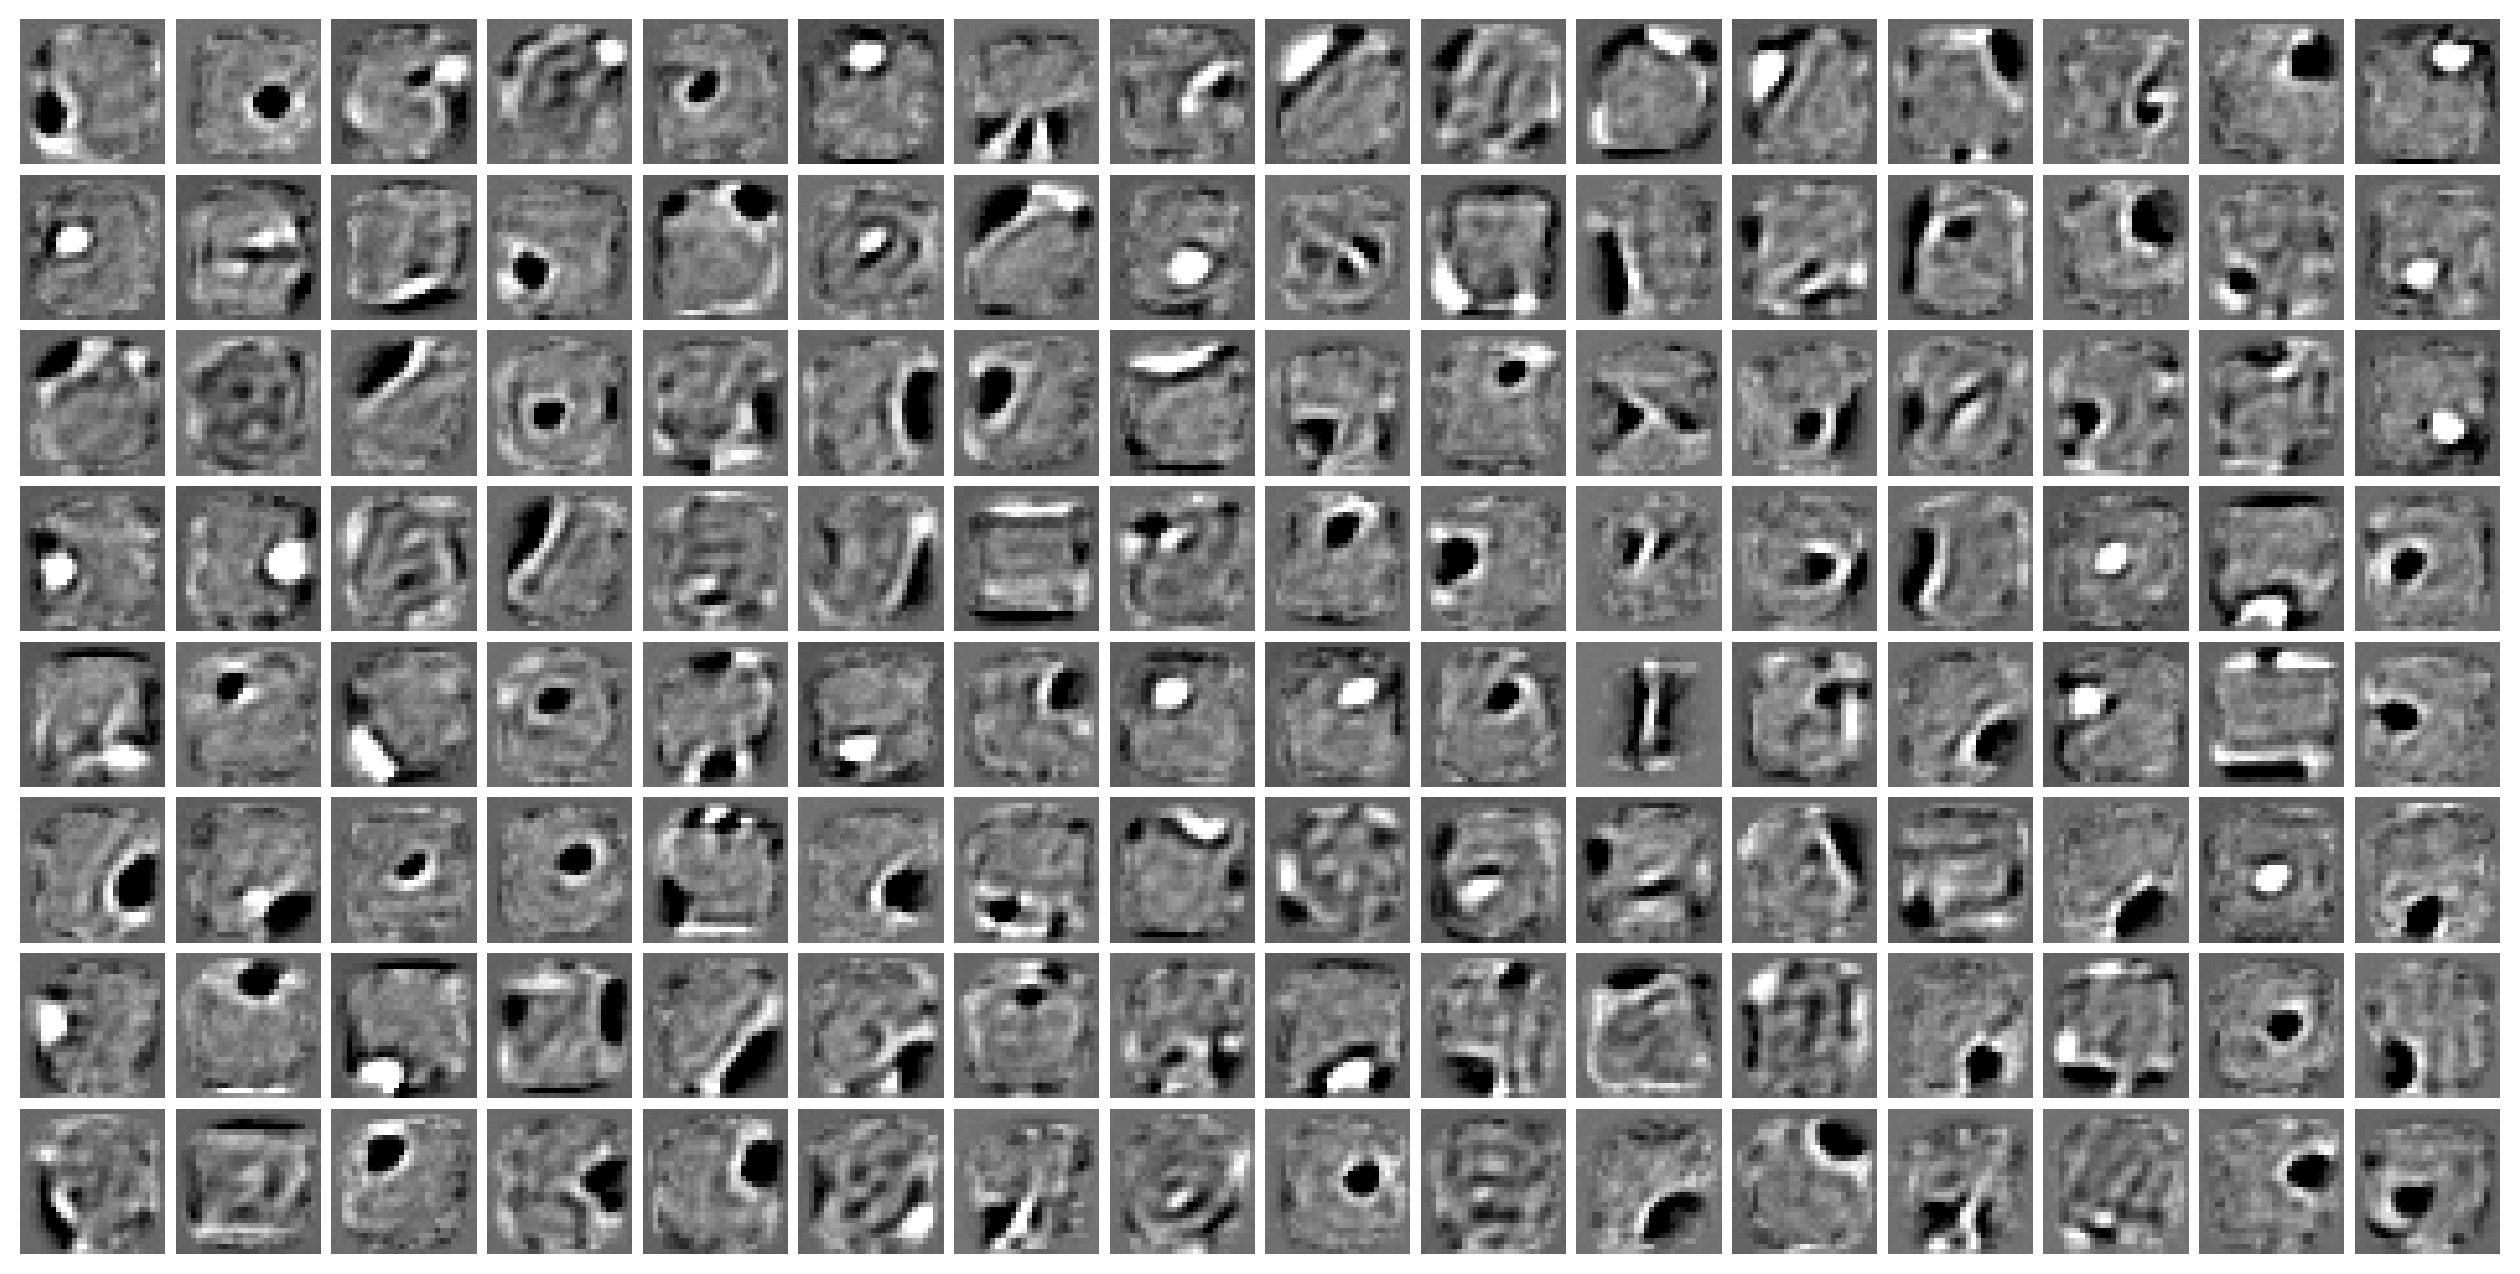

In [11]:
BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

LEARNING_RATE = 0.1
MOMENTUM = 0.5

rbm = RestrictedBoltzmannMachine(VISIBLE_LAYER_SIZE, HIDDEN_LAYER_SIZE, LEARNING_RATE, MOMENTUM)
draw_filters(rbm)

run_training(rbm, dataset, monitoring_set, BATCH_SIZE, EPOCHS_COUNT)

draw_filters(rbm)

# 2. DBN Training

In [12]:
from typing import TypeAlias
DBN: TypeAlias = list[RestrictedBoltzmannMachine]

def propagate_up(
    dbn: DBN,
    layers_count: int,
    visible: np.ndarray,
) -> np.ndarray:
    """
    Forward pass through DBN layers: propagates visible units upward to the target layer.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.
    
    Args:
        dbn: List of RBM layers.
        layers_count: Number of layers to propagate through.
        visible: Input data (minibatch of shape [observations, visible_size]).
    
    Returns:
        Hidden activations at the top layer.
    """
    for i in range(layers_count):
        visible = append_ones(sigmoid(visible @ dbn[i].W[:, :-1]))
    return visible

def propagate_down(
    dbn: DBN,
    layers_count: int,
    hidden: np.ndarray,
) -> np.ndarray:
    """
    Reconstruct data by propagating downward through the DBN.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.

    Args:
        dbn: List of RBM layers forming the DBN.
        layers_count: Number of layers to traverse downward.
        hidden: Hidden representation at the top level.

    Returns:
        Reconstructed visible representation.
    """
    for i in reversed(range(layers_count)):
        hidden = append_ones(sigmoid(hidden @ np.transpose(dbn[i].W[:-1, :])))
    return hidden

### DBN reconstruction error

In [ ]:
def dbn_reconstuction_error(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
) -> float:
    """
    Compute the reconstruction error for a selected DBN layer.

    The minibatch is first propagated upward to the chosen layer,
    then the reconstruction error is evaluated for that RBM.

    Args:
        dbn: List of pretrained RBM layers.
        layer_idx: Index of the RBM layer to evaluate.
        minibatch: Input minibatch.

    Returns:
        Reconstruction error as a scalar value.
    """
    # TODO implement
    raise Exception("Not implemented!")
    
    return error

### Sampling in Deep Belief Networks

In [14]:
def sample_rbm(
    rbm: RestrictedBoltzmannMachine,
    minibatch: np.ndarray,
    steps: int,
) -> np.ndarray:
    """
    Perform Gibbs sampling in a single RBM.

    The procedure alternates between sampling hidden units from visible units
    and reconstructing visible units from hidden units for a given number of steps.

    Args:
        rbm: RBM used for sampling.
        minibatch: Initial visible minibatch.
        steps: Number of Gibbs sampling steps.

    Returns:
        Sampled visible states after the final Gibbs step.
    """
    
    observations_count = minibatch.shape[0]

    visible = minibatch
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    
    for cd_i in range(steps):
        hidden[:, :-1] = sigmoid(visible @ rbm.W[:, :-1])
        hidden[:, :-1] = (hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)
    
        visible[:, :-1] = sigmoid(hidden @ np.transpose(rbm.W[:-1, :]))
        if cd_i < (steps - 1):
            visible[:, :-1] = (visible[:, :-1] > rand(observations_count, rbm.visible_size)).astype(np.float32)

    return visible

In [ ]:
def sample_dbn(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
    steps: int,
) -> np.ndarray:
    """
    Sample from a DBN by propagating upward, sampling in one RBM,
    and propagating the result back downward.
    
    Args:
        dbn: List of RBM layers forming the DBN.
        layer_idx: Index of the RBM layer used for sampling.
        minibatch: Input minibatch.
        steps: Number of Gibbs sampling steps in the selected RBM.

    Returns:
        Reconstructed sample in the visible space.
    """
    
    # TODO implement
    raise Exception("Not implemented!")
    
    return reconstructed

In [16]:
def draw_layer_samples(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
    steps: int = 200,
) -> None:
    """
    Draw and preview image samples reconstructed from a selected DBN layer.

    This helper is useful for visual inspection of generative quality.

    Args:
        dbn: List of RBM layers.
        layer_idx: Index of the sampled layer.
        minibatch: Input minibatch.
        steps: Number of Gibbs sampling steps.
    """
    samples = sample_dbn(dbn, layer_idx, minibatch, steps)
    preview_tiles(np.reshape(samples[:, :-1], shape=(-1, 16, 28, 28)))

### Greedy layer-wise training

In [ ]:
def train_dbn(
    dbn: DBN, 
    layer_idx: int, 
    dataset: np.ndarray, 
    batch_size: int,
) -> None:
    """
    Train one DBN layer using greedy layer-wise pretraining.

    The dataset is first propagated through all previously trained layers.
    Then the selected RBM layer is trained on minibatches.

    Args:
        dbn: List of RBM layers.
        layer_idx: Index of the RBM layer to train.
        dataset: Full training dataset.
        batch_size: Minibatch size.
    """
    
    # TODO implement
    # dataset = what_function(..., dataset, ...)
    raise Exception("Not implemented!")
    
    
    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(dbn[layer_idx], batch)
        if batch_idx % round(batches_limit / 50) == 0: print("#", end="")

In [18]:
BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

LEARNING_RATE: float = 0.1
MOMENTUM: float = 0.5

DBN_HIDDEN_LAYER_SIZE: int = 200

dbn: DBN = [
    RestrictedBoltzmannMachine(
        VISIBLE_LAYER_SIZE,
        DBN_HIDDEN_LAYER_SIZE,
        LEARNING_RATE,
        MOMENTUM,
    ),
    RestrictedBoltzmannMachine(
        DBN_HIDDEN_LAYER_SIZE,
        DBN_HIDDEN_LAYER_SIZE,
        LEARNING_RATE,
        MOMENTUM,
    ),
    RestrictedBoltzmannMachine(
        DBN_HIDDEN_LAYER_SIZE,
        DBN_HIDDEN_LAYER_SIZE,
        LEARNING_RATE,
        MOMENTUM,
    ),
]

for layer_idx in range(len(dbn)):
    print(f"\nLearning layer {layer_idx}")

    for epoch in range(EPOCHS_COUNT):
        print(f"Epoch {epoch}:", end="\t")

        if epoch == 5:
            dbn[layer_idx].momentum = 0.8

        start_time = time.time()
        train_dbn(dbn, layer_idx, dataset, BATCH_SIZE)
        elapsed = time.time() - start_time

        error = dbn_reconstuction_error(dbn, layer_idx, monitoring_set)
        print(f"\telapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")
    
print("Training finished!")


Learning layer 0
Epoch 0:	#####################################################	elapsed: 0.88s, reconstruction error: 24.53
Epoch 1:	#####################################################	elapsed: 1.07s, reconstruction error: 19.23
Epoch 2:	#####################################################	elapsed: 1.21s, reconstruction error: 16.77
Epoch 3:	#####################################################	elapsed: 1.12s, reconstruction error: 15.16
Epoch 4:	#####################################################	elapsed: 1.40s, reconstruction error: 14.13
Epoch 5:	#####################################################	elapsed: 0.85s, reconstruction error: 12.89
Epoch 6:	#####################################################	elapsed: 0.79s, reconstruction error: 11.94
Epoch 7:	#####################################################	elapsed: 1.18s, reconstruction error: 11.42
Epoch 8:	#####################################################	elapsed: 2.23s, reconstruction error: 10.79
Epoch 9:	##########

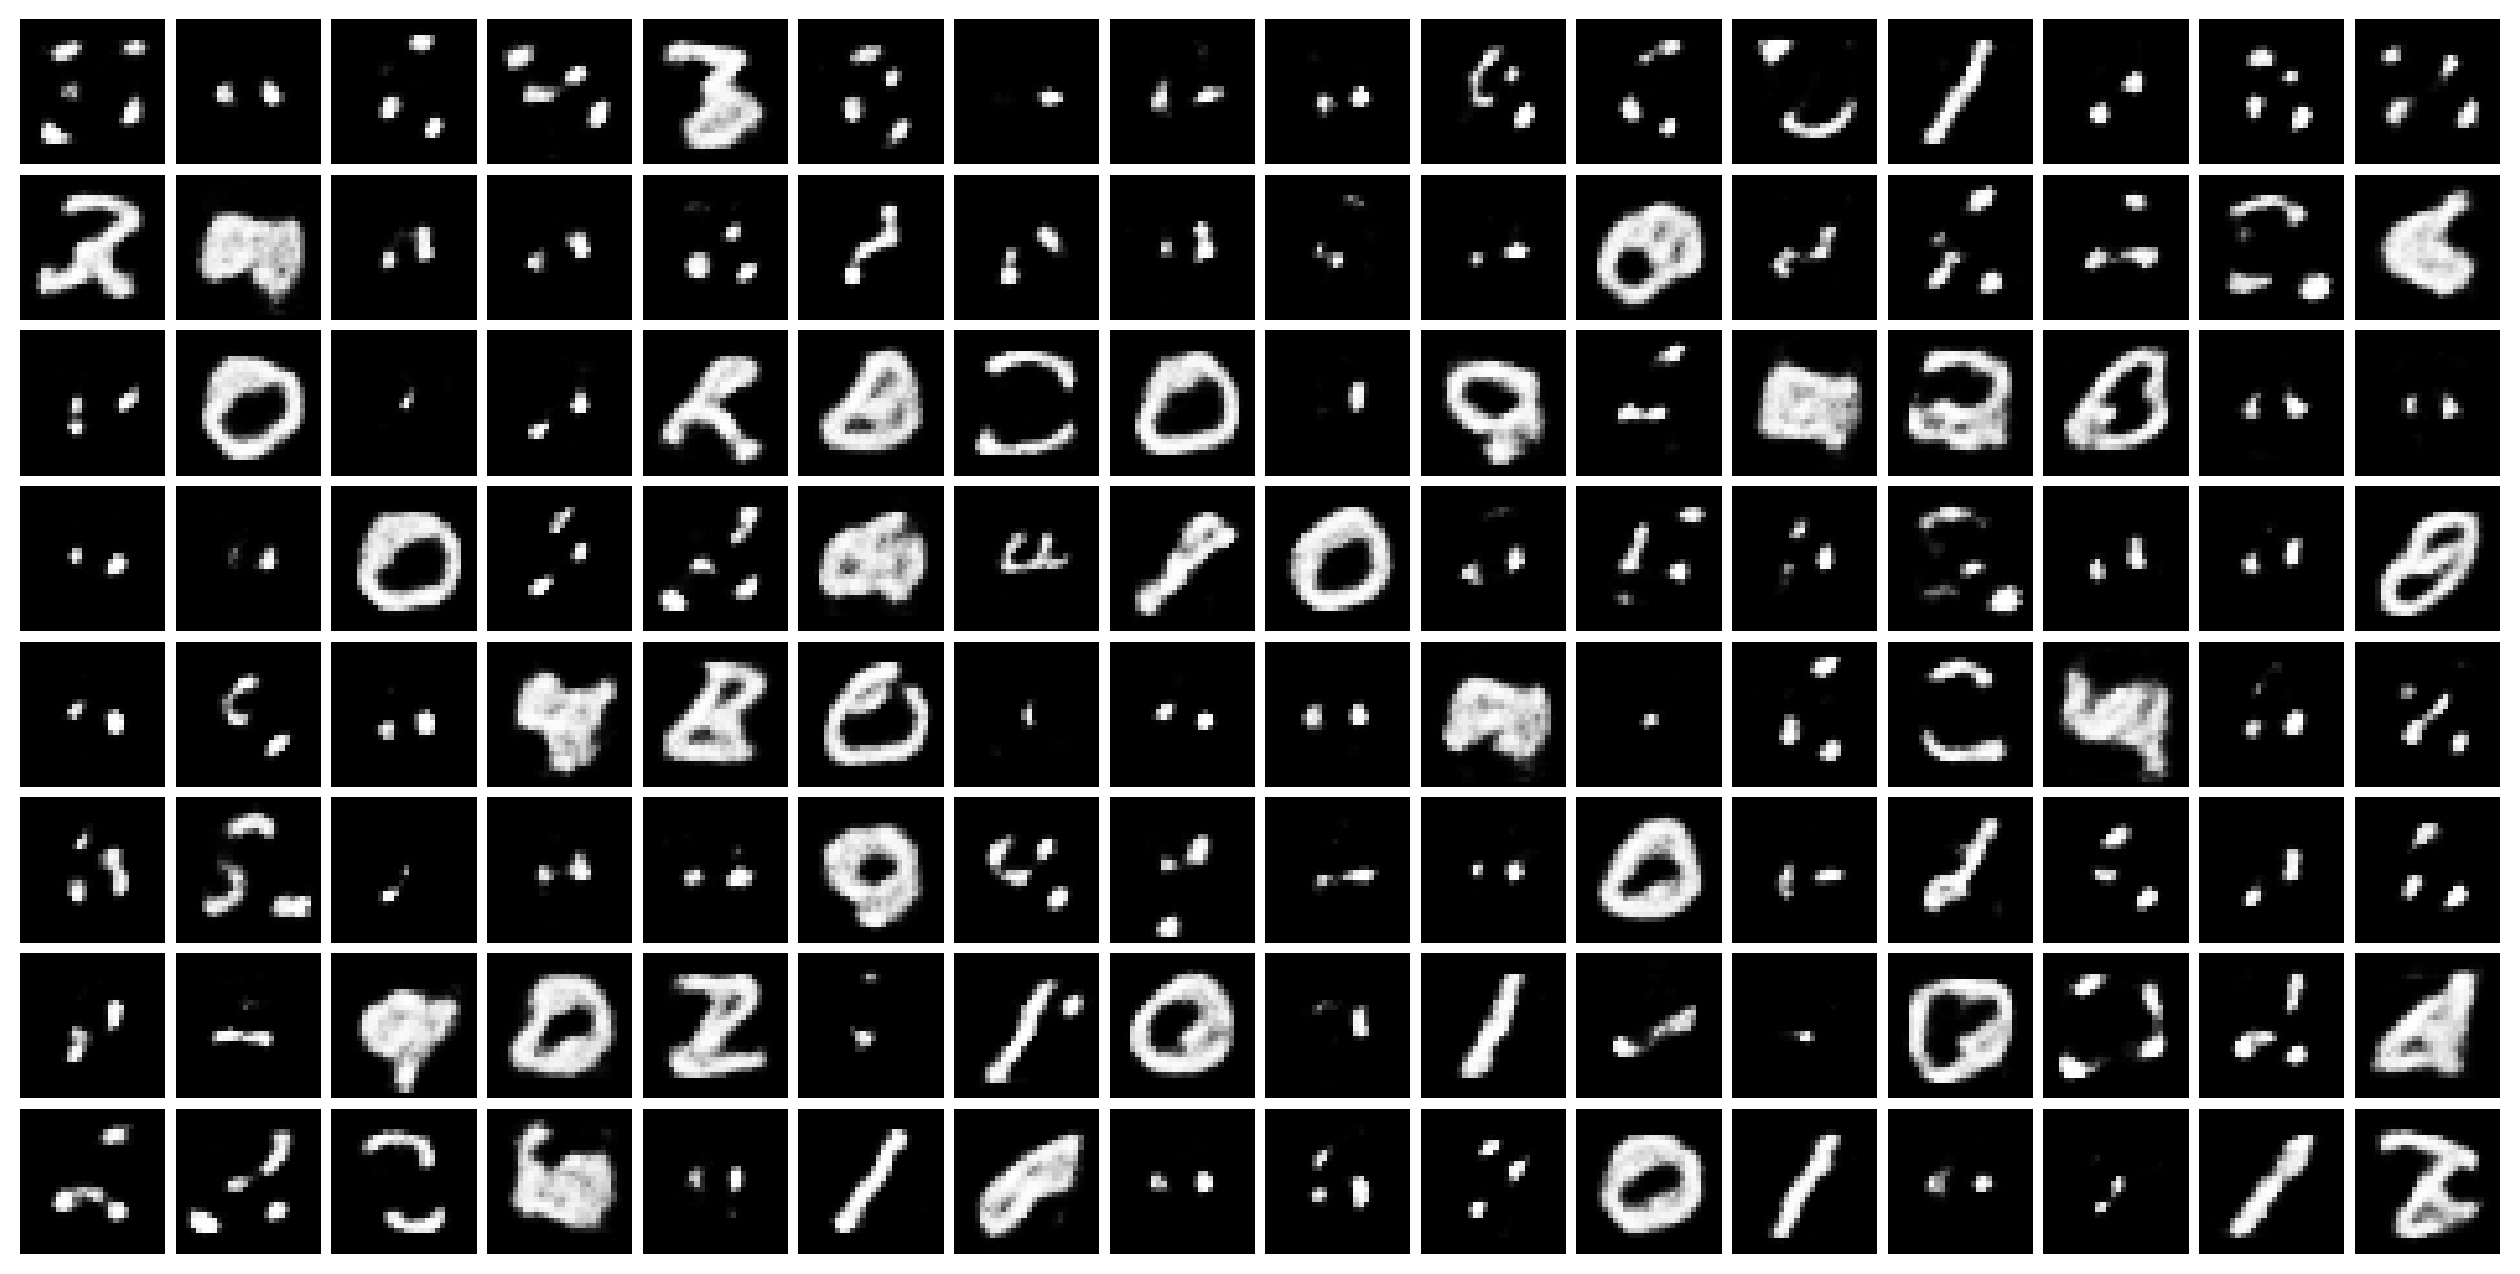

In [19]:
draw_layer_samples(dbn, 0, monitoring_set[:8*16])

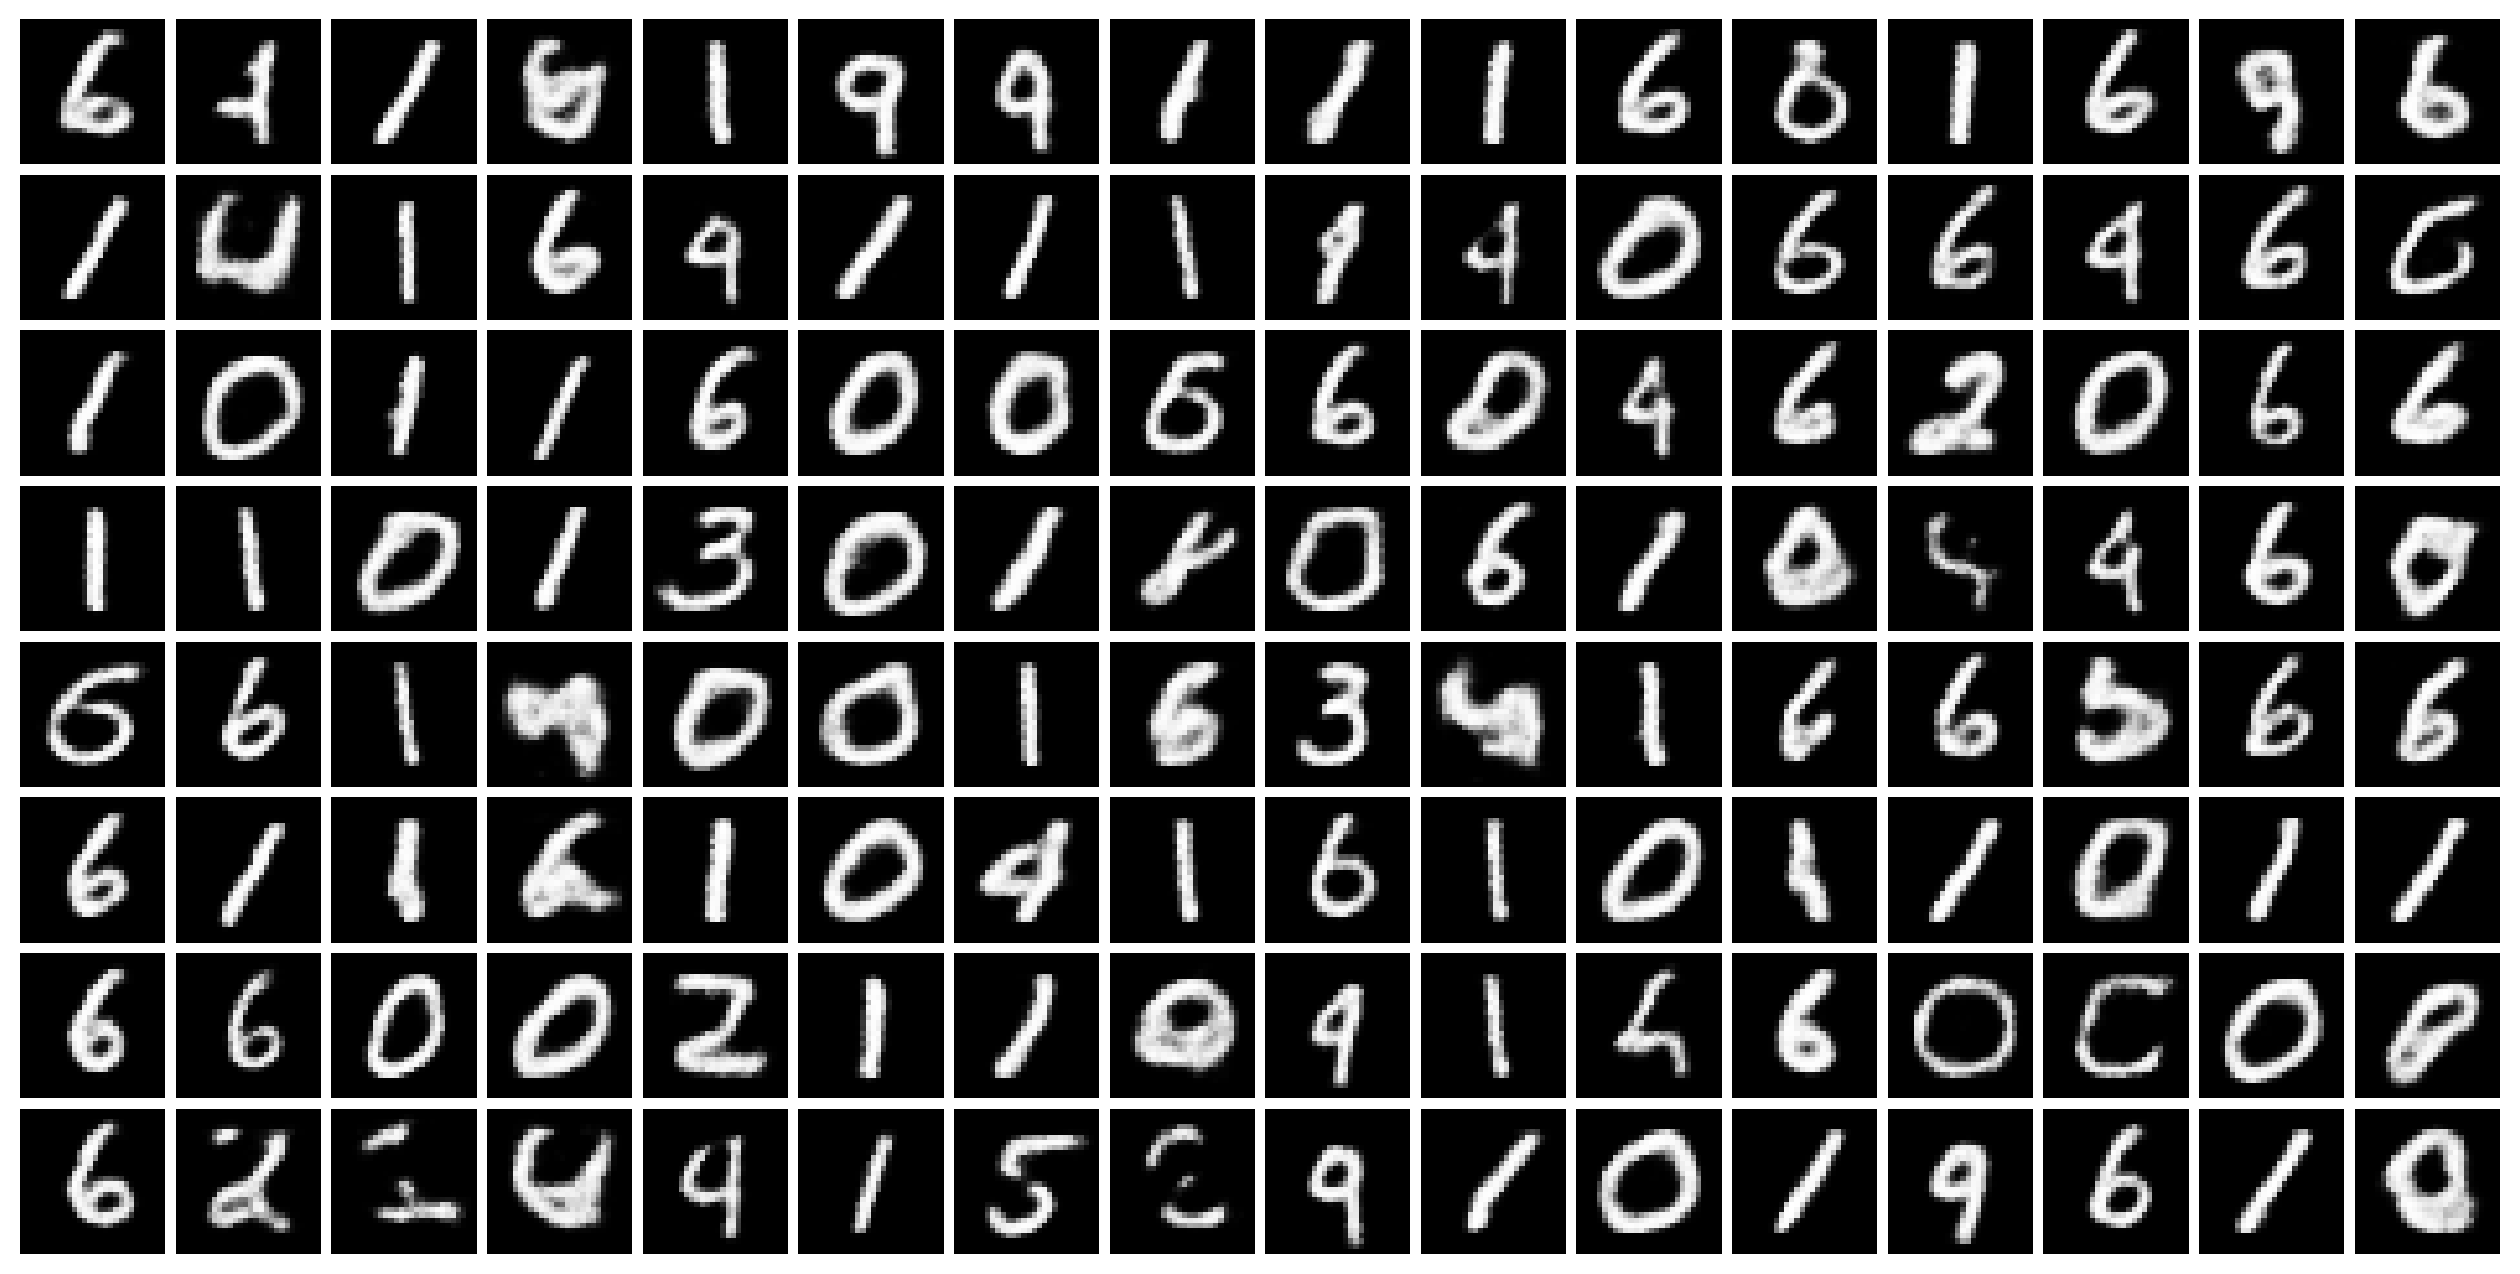

In [20]:
draw_layer_samples(dbn, 1, monitoring_set[:8*16])

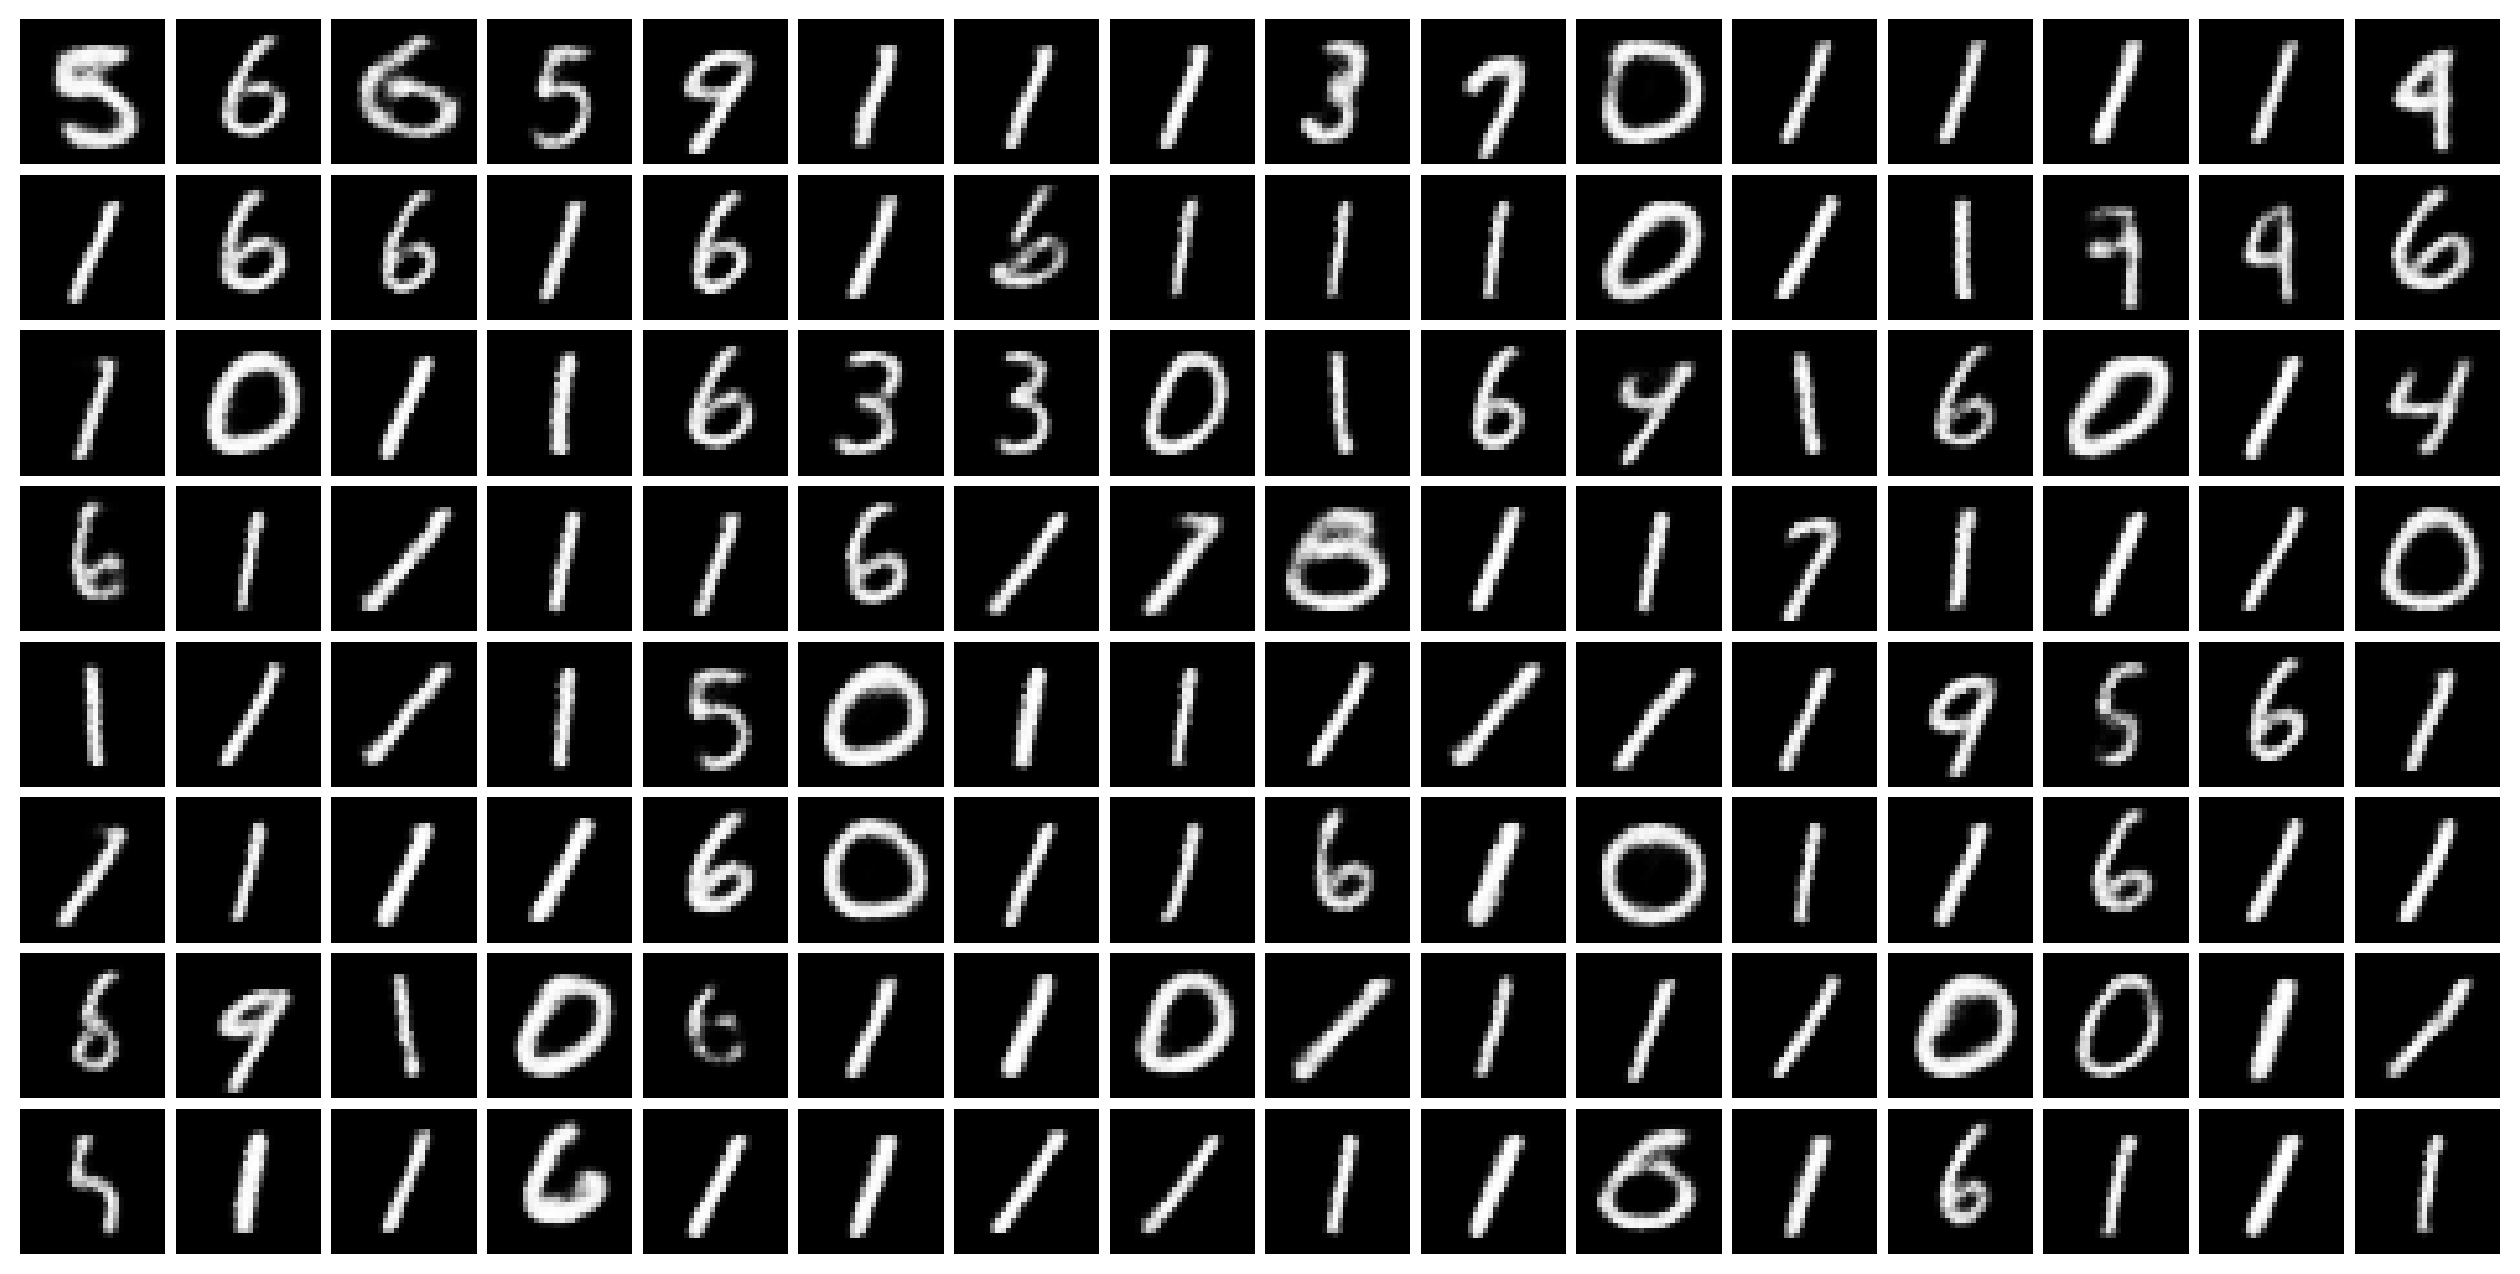

In [21]:
draw_layer_samples(dbn, 2, monitoring_set[:8*16])

## Additional links

* [YouTube - Hugo Larochelle | Neural networks [7.7] : Deep learning - deep belief network](https://www.youtube.com/watch?v=vkb6AWYXZ5I)